<a href="https://colab.research.google.com/github/kixcz/ml-projects-compilation/blob/main/KNN_regression_and_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Nearest Neighbors (KNN): Classification and Regression
**Google Colab | Synthetic datasets | Visual explanations**

### Learning objectives
- **Classification:** predict a category using majority voting among the K nearest points.
- **Regression:** predict a numerical value using the average target of the K nearest points.
- Visualize neighbor distances, classification decision boundaries, regression curves, K selection, and evaluation metrics.

Run **Runtime → Run all**. The dummy datasets are generated in the notebook; no files or package installation required.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor, NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

SEED = 42
COLORS = ["#2563eb", "#f97316"]
CMAP = ListedColormap(COLORS)
plt.rcParams.update({"figure.figsize": (8, 5.5), "axes.grid": True, "grid.alpha": 0.18, "font.size": 11})
print("Libraries imported. Random seed:", SEED)

Libraries imported. Random seed: 42


## PART A — KNN CLASSIFICATION

Predict a **category** (Group A or Group B) from two numerical features. The colored regions on decision-boundary diagrams show predicted classes.

In [2]:
X_raw, y = make_blobs(n_samples=140, centers=[(3.0, 38.0), (7.1, 76.0)], cluster_std=[1.65, 1.9], random_state=SEED)
# Both displayed axes have understandable units; training uses standardized features later.
df = pd.DataFrame({"Practice hours": X_raw[:, 0], "Quiz score": X_raw[:, 1], "Group": np.where(y == 0, "Group A", "Group B")})
display(df.head(10))
print("Class counts:\n", df["Group"].value_counts().to_string())

,Practice hours,Quiz score,Group
0,4.836523,77.247452,Group B
1,7.210597,73.828356,Group B
2,3.968314,41.614252,Group A
3,7.999151,75.861625,Group B
4,8.078567,76.976193,Group B
5,5.409923,74.449960,Group B
6,-0.165973,37.956252,Group A
7,6.251622,77.627158,Group B
8,5.235134,76.877997,Group B
9,4.885658,39.240690,Group A


Class counts:
 Group
Group B    70
Group A    70


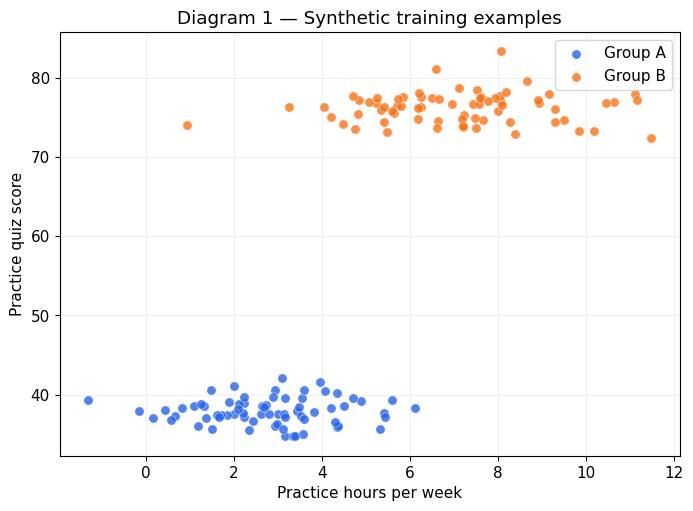

In [3]:
fig, ax = plt.subplots()
for label, c in [(0, COLORS[0]), (1, COLORS[1])]:
    pts = X_raw[y == label]
    ax.scatter(pts[:, 0], pts[:, 1], s=45, color=c, alpha=0.8, label=f"Group {chr(65+label)}", edgecolor="white", linewidth=0.4)
ax.set(xlabel="Practice hours per week", ylabel="Practice quiz score", title="Diagram 1 — Synthetic training examples")
ax.legend()
plt.show()

## 2. How KNN works: find the closest K points
We split the data **before** fitting the scaler to prevent data leakage. The classifier uses standardized inputs because quiz scores and practice hours use different numeric scales.

The highlighted new point comes from the held-out test set; it is not included in the training examples. **K = 5** means KNN inspects the five nearest training observations.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.25, stratify=y, random_state=SEED)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
new_raw = X_test[0]
new_scaled = X_test_scaled[0]
K = 5
neighbors = NearestNeighbors(n_neighbors=K).fit(X_train_scaled)
distances, indices = neighbors.kneighbors([new_scaled])
neighbor_labels = y_train[indices[0]]
predicted_group = np.bincount(neighbor_labels, minlength=2).argmax()
neighbor_table = pd.DataFrame({"Rank": np.arange(1,K+1), "Training index": indices[0], "Scaled Euclidean distance": distances[0].round(3), "Group": [f"Group {chr(65+v)}" for v in neighbor_labels]})
display(neighbor_table)
print(f"Prediction: Group {chr(65+predicted_group)}; actual held-out label: Group {chr(65+y_test[0])}")

,Rank,Training index,Scaled Euclidean distance,Group
0,1,30,0.043,Group B
1,2,88,0.055,Group B
2,3,23,0.071,Group B
3,4,40,0.086,Group B
4,5,35,0.094,Group B


Prediction: Group B; actual held-out label: Group B


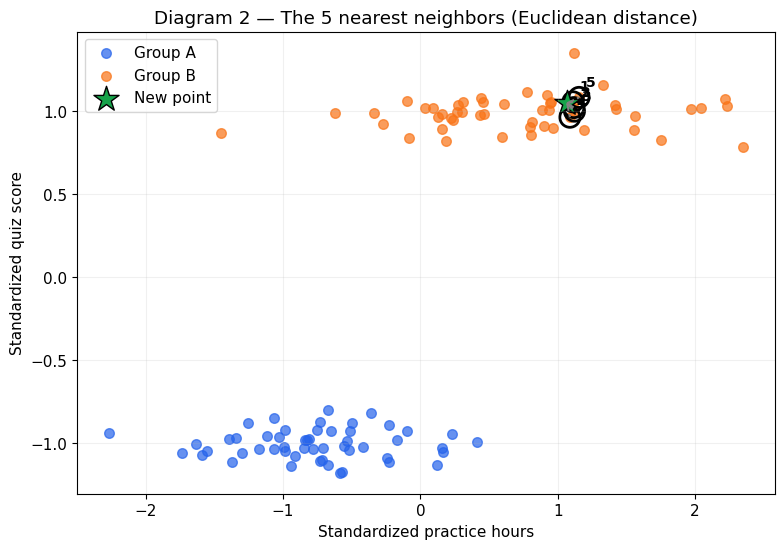

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
for label, c in [(0, COLORS[0]), (1, COLORS[1])]:
    pts = X_train_scaled[y_train == label]
    ax.scatter(pts[:, 0], pts[:, 1], s=48, alpha=0.7, color=c, label=f"Group {chr(65+label)}")
for rank, idx in enumerate(indices[0], 1):
    p = X_train_scaled[idx]
    ax.plot([new_scaled[0], p[0]], [new_scaled[1], p[1]], "--", color="gray", linewidth=1.5)
    ax.scatter(p[0], p[1], s=210, facecolors="none", edgecolors="black", linewidths=2)
    ax.annotate(str(rank), (p[0], p[1]), xytext=(5, 8), textcoords="offset points", fontsize=10, weight="bold")
ax.scatter(*new_scaled, marker="*", s=360, color="#16a34a", edgecolor="black", label="New point")
ax.set(xlabel="Standardized practice hours", ylabel="Standardized quiz score", title=f"Diagram 2 — The {K} nearest neighbors (Euclidean distance)")
ax.legend(loc="best")
plt.show()

**Distance formula (after standardization):**

$$d(\mathbf{x},\mathbf{z})=\sqrt{(x_1-z_1)^2+(x_2-z_2)^2}$$

KNN takes a **majority vote** among neighbors for classification. Distance here is measured in standardized feature units, not original hours or quiz points.

## 3. Decision boundaries: small K vs large K
Small K can produce detailed, irregular boundaries (higher variance). Large K creates smoother boundaries, but may underfit. The optimal K is data-dependent; avoid claiming that K=5 is universally best.

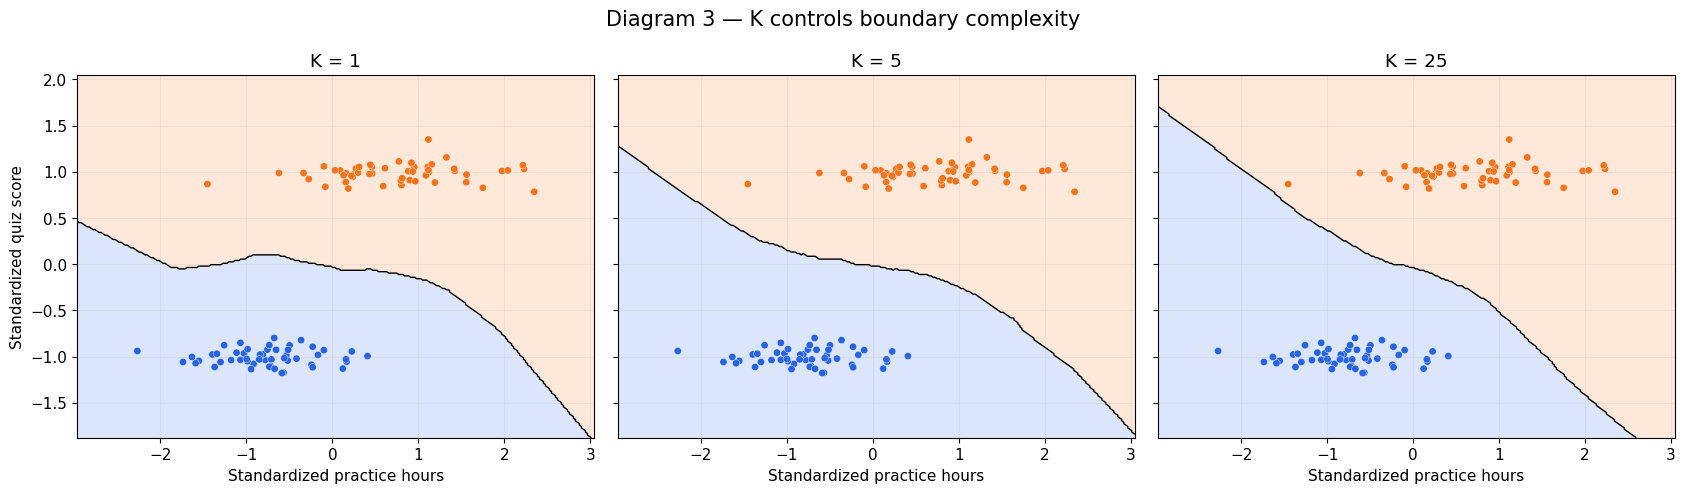

In [6]:
xx, yy = np.meshgrid(np.linspace(X_train_scaled[:,0].min()-0.7, X_train_scaled[:,0].max()+0.7, 260), np.linspace(X_train_scaled[:,1].min()-0.7, X_train_scaled[:,1].max()+0.7, 260))
grid = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
for ax, k in zip(axes, [1, 5, 25]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    zz = knn.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-0.5,0.5,1.5], colors=COLORS, alpha=0.16)
    ax.contour(xx, yy, zz, levels=[0.5], colors=["black"], linewidths=1)
    ax.scatter(X_train_scaled[:,0], X_train_scaled[:,1], c=y_train, cmap=CMAP, vmin=0, vmax=1, s=28, edgecolor="white", linewidth=0.3)
    ax.set_title(f"K = {k}")
    ax.set_xlabel("Standardized practice hours")
axes[0].set_ylabel("Standardized quiz score")
fig.suptitle("Diagram 3 — K controls boundary complexity", fontsize=15)
plt.tight_layout()
plt.show()

## 4. Choose K using cross-validation
We compare **5-fold stratified cross-validation accuracy on training data only**, so the test set stays unseen until final evaluation. We fit a new scaler within each CV fold using a pipeline.

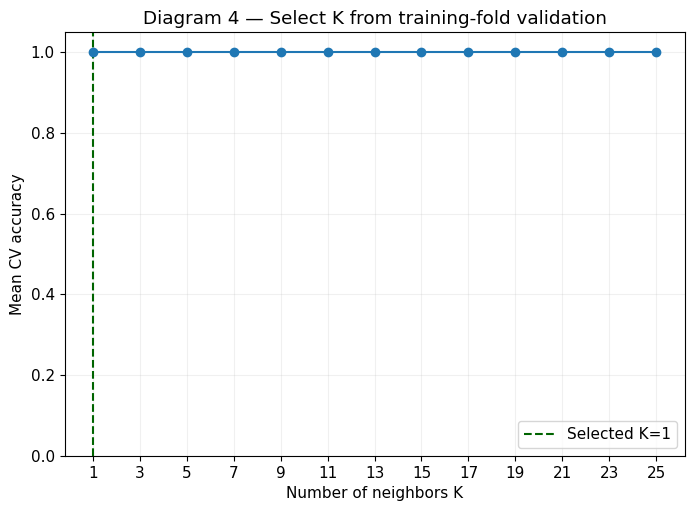

Selected K: 1 (highest mean CV accuracy; first value breaks ties)


In [7]:
k_values = list(range(1, 26, 2))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_means, cv_stds = [], []
for k in k_values:
    pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy")
    cv_means.append(scores.mean()); cv_stds.append(scores.std())
best_k = k_values[int(np.argmax(cv_means))]
fig, ax = plt.subplots()
ax.errorbar(k_values, cv_means, yerr=cv_stds, fmt="o-", capsize=3)
ax.axvline(best_k, color="darkgreen", linestyle="--", label=f"Selected K={best_k}")
ax.set(xlabel="Number of neighbors K", ylabel="Mean CV accuracy", title="Diagram 4 — Select K from training-fold validation", xticks=k_values, ylim=(0,1.05))
ax.legend()
plt.show()
print(f"Selected K: {best_k} (highest mean CV accuracy; first value breaks ties)")

## 5. Final classification test and confusion matrix
Use the selected K to fit the entire training set, then evaluate once on the held-out test set.

Held-out accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

     Group A       1.00      1.00      1.00        18
     Group B       1.00      1.00      1.00        17

    accuracy                           1.00        35
   macro avg       1.00      1.00      1.00        35
weighted avg       1.00      1.00      1.00        35



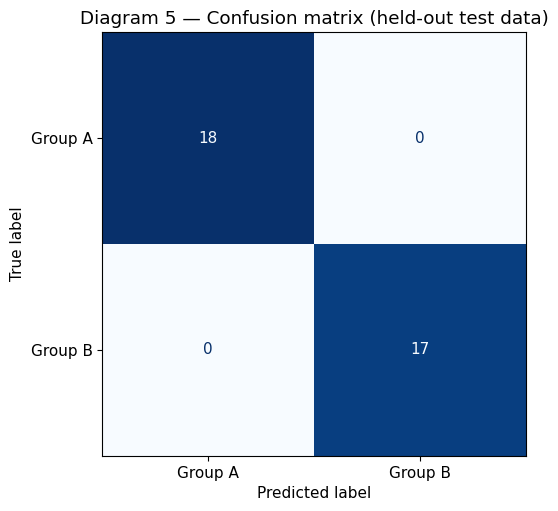

In [8]:
final_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
print("Held-out accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification report:\n", classification_report(y_test, y_pred, target_names=["Group A", "Group B"], zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Group A", "Group B"], cmap="Blues", colorbar=False)
plt.title("Diagram 5 — Confusion matrix (held-out test data)")
plt.grid(False)
plt.show()

## 6. Why scaling features matters
To isolate the effect of feature scale, compare KNN on **unscaled** vs **scaled** coordinates at the *same* K. Here quiz scores span a larger numeric range than practice hours, which can dominate unscaled Euclidean distance.

,Configuration,Test accuracy
0,Without scaling,1.0
1,With standardization,1.0


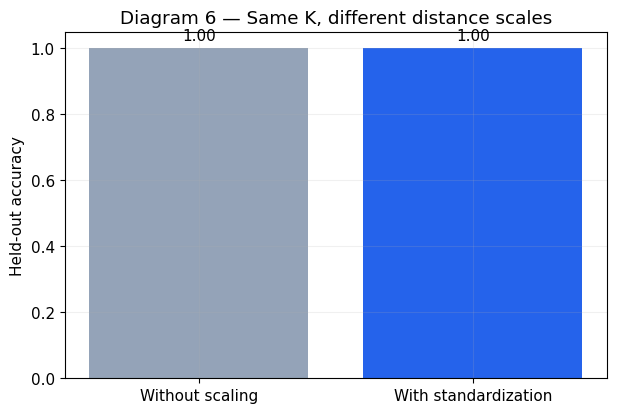

Note: Accuracy may match despite different distance geometry; scaling is still important when feature units differ.


In [9]:
models = {
    "Without scaling": KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train),
    "With standardization": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k)).fit(X_train, y_train)
}
comparison = pd.DataFrame([{"Configuration": name, "Test accuracy": accuracy_score(y_test, model.predict(X_test))} for name, model in models.items()])
display(comparison)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(comparison["Configuration"], comparison["Test accuracy"], color=["#94a3b8", "#2563eb"])
ax.set(ylabel="Held-out accuracy", title="Diagram 6 — Same K, different distance scales", ylim=(0, 1.05))
for i, score in enumerate(comparison["Test accuracy"]): ax.text(i, score+0.025, f"{score:.2f}", ha="center")
plt.show()
print("Note: Accuracy may match despite different distance geometry; scaling is still important when feature units differ.")

## PART B — KNN REGRESSION

Predict a **continuous number** from a numerical input. Unlike classification, a KNN regressor takes the **mean** of the selected neighbors’ target values (when `weights="uniform"`).

$$\hat{y}(x)=\frac{1}{K}\sum_{i\in N_K(x)}y_i$$

Our synthetic example uses an input feature between 0 and 10 and a continuous target. **The features are illustrative**, not authentic student grades or performance data.

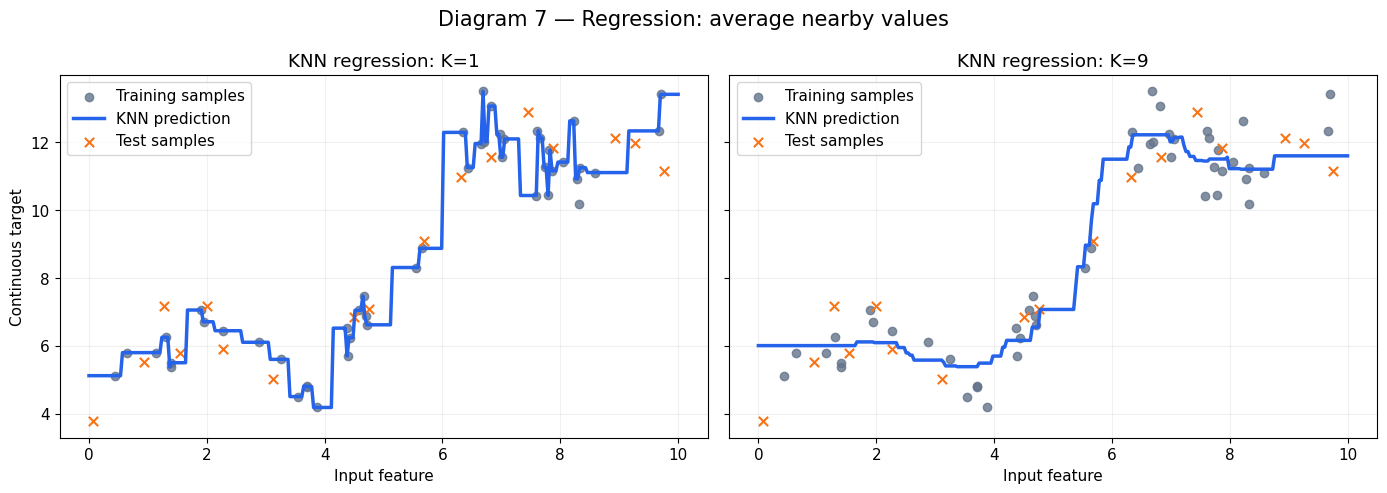

Test MAE: 0.755
Test RMSE: 0.907
Test R²: 0.903


In [10]:
rng = np.random.default_rng(SEED)
x_reg = np.sort(rng.uniform(0, 10, 65))
y_reg = 3 + 1.1*x_reg + 2*np.sin(1.2*x_reg) + rng.normal(0, 0.9, len(x_reg))
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg.reshape(-1,1), y_reg, test_size=0.25, random_state=SEED)
x_line = np.linspace(0, 10, 300).reshape(-1,1)
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True, sharey=True)
for ax, k in zip(axes, [1, 9]):
    model = KNeighborsRegressor(n_neighbors=k).fit(x_train_reg, y_train_reg)
    ax.scatter(x_train_reg, y_train_reg, color="#64748b", alpha=0.8, label="Training samples")
    ax.plot(x_line, model.predict(x_line), color=COLORS[0], linewidth=2.5, label="KNN prediction")
    ax.scatter(x_test_reg, y_test_reg, s=45, marker="x", color=COLORS[1], label="Test samples")
    ax.set(title=f"KNN regression: K={k}", xlabel="Input feature")
    ax.legend()
axes[0].set_ylabel("Continuous target")
fig.suptitle("Diagram 7 — Regression: average nearby values", fontsize=15)
plt.tight_layout()
plt.show()
reg = KNeighborsRegressor(n_neighbors=9).fit(x_train_reg, y_train_reg)
reg_predictions = reg.predict(x_test_reg)
print(f"Test MAE: {mean_absolute_error(y_test_reg, reg_predictions):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_reg, reg_predictions)):.3f}")
print(f"Test R²: {r2_score(y_test_reg, reg_predictions):.3f}")

### Regression: visualize exactly which neighbors are averaged

Choose a new input (`query_x = 5.0`) and `K = 5`. The highlighted neighbors determine the predicted **number**, and the horizontal dashed line marks their average.

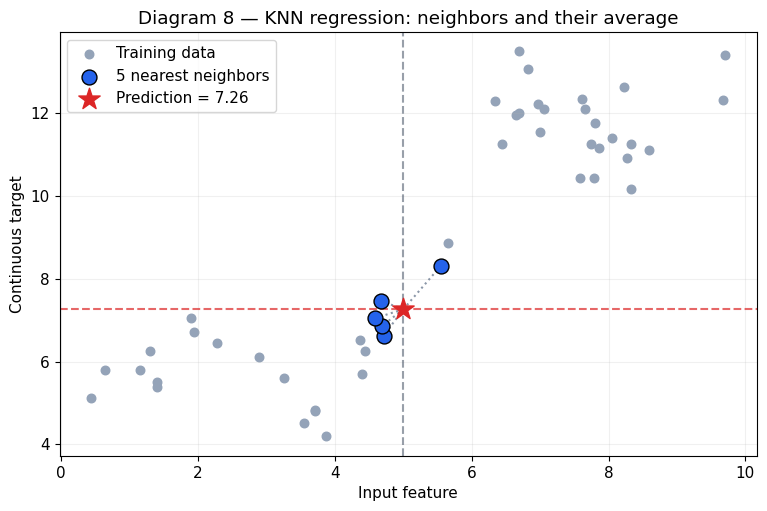

Neighbor target values: [6.62, 6.87, 7.47, 7.05, 8.31]
Their average (predicted value): 7.26


In [11]:
query_x = 5.0
k_reg_demo = 5
reg_demo = KNeighborsRegressor(n_neighbors=k_reg_demo)
reg_demo.fit(x_train_reg, y_train_reg)
distances, indices = reg_demo.kneighbors([[query_x]])
neighbor_x = x_train_reg[indices[0], 0]
neighbor_y = y_train_reg[indices[0]]
predicted_number = reg_demo.predict([[query_x]])[0]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(x_train_reg[:,0], y_train_reg, color="#94a3b8", label="Training data", s=38)
ax.scatter(neighbor_x, neighbor_y, s=115, color="#2563eb", edgecolor="black", label=f"{k_reg_demo} nearest neighbors", zorder=3)
for nx, ny in zip(neighbor_x, neighbor_y):
    ax.plot([query_x, nx], [predicted_number, ny], linestyle=":", color="#64748b", alpha=0.75)
ax.scatter([query_x], [predicted_number], marker="*", color="#dc2626", s=260, label=f"Prediction = {predicted_number:.2f}", zorder=4)
ax.axhline(predicted_number, linestyle="--", color="#dc2626", alpha=0.7)
ax.axvline(query_x, linestyle="--", color="#334155", alpha=0.5)
ax.set(xlabel="Input feature", ylabel="Continuous target", title="Diagram 8 — KNN regression: neighbors and their average")
ax.legend(); plt.show()
print("Neighbor target values:", np.round(neighbor_y, 2).tolist())
print("Their average (predicted value):", round(predicted_number, 2))

### Regression: see how K changes the prediction curve

- **K = 1** follows individual samples closely and can be sensitive to noise.
- **Larger K** smooths the curve, but a very large K may miss useful local patterns.

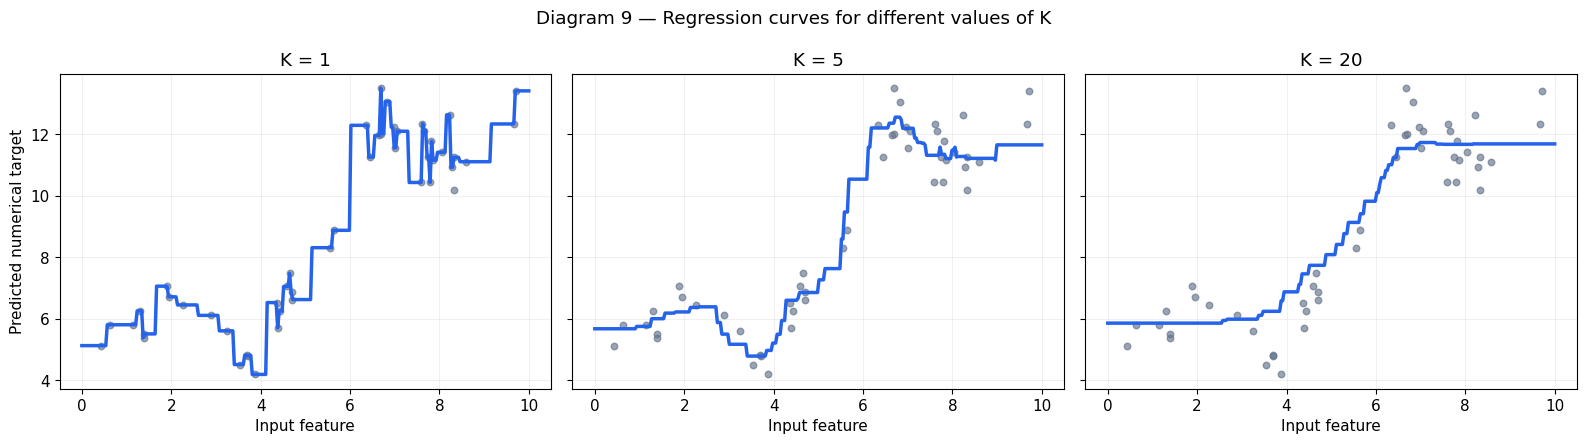

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
for ax, k in zip(axes, [1, 5, 20]):
    reg_k = KNeighborsRegressor(n_neighbors=k).fit(x_train_reg, y_train_reg)
    ax.scatter(x_train_reg[:, 0], y_train_reg, color="#64748b", s=22, alpha=0.65)
    ax.plot(x_line[:, 0], reg_k.predict(x_line), color="#2563eb", linewidth=2.5)
    ax.set(title=f"K = {k}", xlabel="Input feature")
axes[0].set_ylabel("Predicted numerical target")
fig.suptitle("Diagram 9 — Regression curves for different values of K")
plt.tight_layout(); plt.show()

### Regression: choose K using cross-validation

Use the **training set only** to compare candidate values of K, with 5-fold cross-validation and mean absolute error (MAE). Then evaluate the selected model on the untouched test set. A **lower MAE** is better.

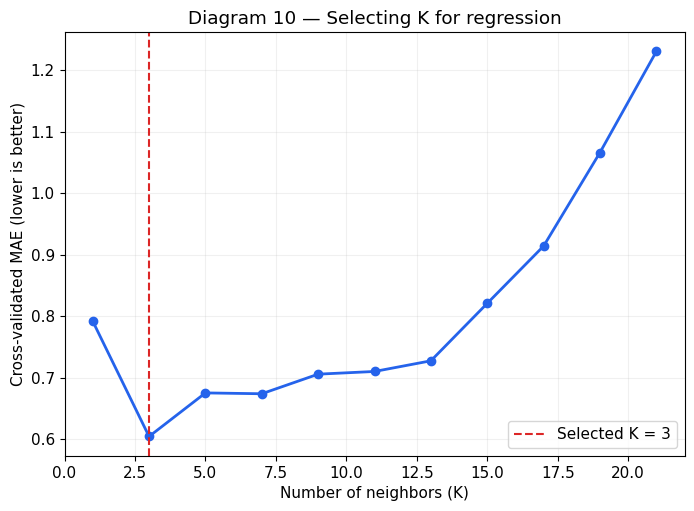

Selected regression K: 3


In [13]:
from sklearn.model_selection import KFold

reg_ks = list(range(1, 22, 2))
reg_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
reg_maes = []
for k in reg_ks:
    scores = cross_val_score(KNeighborsRegressor(n_neighbors=k), x_train_reg, y_train_reg,
                              cv=reg_cv, scoring="neg_mean_absolute_error")
    reg_maes.append(-scores.mean())
best_reg_k = reg_ks[int(np.argmin(reg_maes))]
fig, ax = plt.subplots()
ax.plot(reg_ks, reg_maes, marker="o", linewidth=2, color="#2563eb")
ax.axvline(best_reg_k, color="#dc2626", linestyle="--", label=f"Selected K = {best_reg_k}")
ax.set(xlabel="Number of neighbors (K)", ylabel="Cross-validated MAE (lower is better)", title="Diagram 10 — Selecting K for regression")
ax.legend(); plt.show()
print("Selected regression K:", best_reg_k)

### Regression: predicted vs actual values

The dashed diagonal represents **perfect predictions**. The closer the test observations are to this line, the more accurate the regression predictions. Report MAE, RMSE, and R² alongside the diagram.

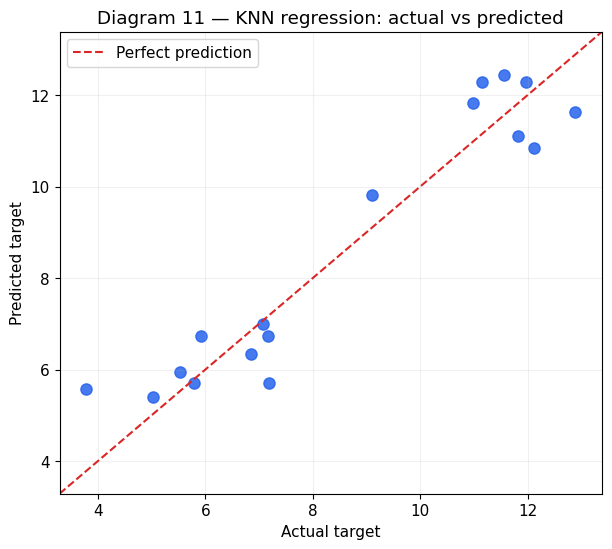

Held-out regression test | K=3 | MAE=0.774 | RMSE=0.907 | R²=0.903
   Actual  Predicted  Absolute error
0   11.83      11.12            0.71
1   12.12      10.84            1.29
2    3.79       5.58            1.79
3   12.89      11.63            1.26
4    7.18       5.71            1.47
5   11.96      12.28            0.32
6    5.02       5.41            0.39
7    7.17       6.74            0.43


In [14]:
final_reg = KNeighborsRegressor(n_neighbors=best_reg_k).fit(x_train_reg, y_train_reg)
y_hat_reg = final_reg.predict(x_test_reg)
mae = mean_absolute_error(y_test_reg, y_hat_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_hat_reg))
r2 = r2_score(y_test_reg, y_hat_reg)
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(y_test_reg, y_hat_reg, color="#2563eb", s=65, alpha=0.85)
lims = [min(y_test_reg.min(), y_hat_reg.min()) - 0.5, max(y_test_reg.max(), y_hat_reg.max()) + 0.5]
ax.plot(lims, lims, "--", color="#dc2626", label="Perfect prediction")
ax.set(xlim=lims, ylim=lims, xlabel="Actual target", ylabel="Predicted target", title="Diagram 11 — KNN regression: actual vs predicted")
ax.legend(); plt.show()
print(f"Held-out regression test | K={best_reg_k} | MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")
print(pd.DataFrame({"Actual": y_test_reg, "Predicted": y_hat_reg, "Absolute error": np.abs(y_test_reg-y_hat_reg)}).head(8).round(2))

## Classification vs regression — quick comparison

| | KNN Classification | KNN Regression |
|---|---|---|
| Output | Category (e.g., Group A / B) | Continuous number |
| Combining neighbors | Majority vote | Mean of target values (uniform weights) |
| Main diagrams | Nearest-neighbor vote, decision boundary, confusion matrix | Neighbor averaging, fitted curves, actual vs predicted |
| Typical metrics | Accuracy, precision, recall, F1 | MAE, RMSE, R² |

**Important:** fit any preprocessing (for example standardization) **on the training data only**, and select K without using the held-out test data.

## Student exercises and wrap-up

**Classification:** majority vote of the K nearest points. **Regression:** average of neighbors' target values. **Distance metric:** Euclidean distance (here). **Important considerations:** scaling, K selection, leakage prevention, imbalanced classes, outliers, and slower prediction on large datasets.

**Try these activities:**
1. Change K in Diagram 2 from `5` to `3` or `9`. Which points are selected?
2. Compare boundaries for K = `1`, `7`, and `35`. What changes?
3. Change the dataset's `cluster_std` to `[3.5, 3.5]`, rerun, and inspect test accuracy.
4. Explain the diagonal of the confusion matrix and the off-diagonal errors.
5. In KNN regression, compare K = `1`, `5`, and `15`: which curve is smoother?

**Teaching caveat:** all outcomes arise from synthetic examples; they cannot be generalized to real students or other datasets.